#### 1. Time Series Analysis: Do it on ice cream sales dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('ice_cream.csv')
df.head()

,date,sale
0,1972-01-01,59.9622
1,1972-02-01,67.0605
2,1972-03-01,74.2350
3,1972-04-01,78.1120
4,1972-05-01,84.7636


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    577 non-null    object 
 1   sale    577 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.1+ KB


### Visualize initial data

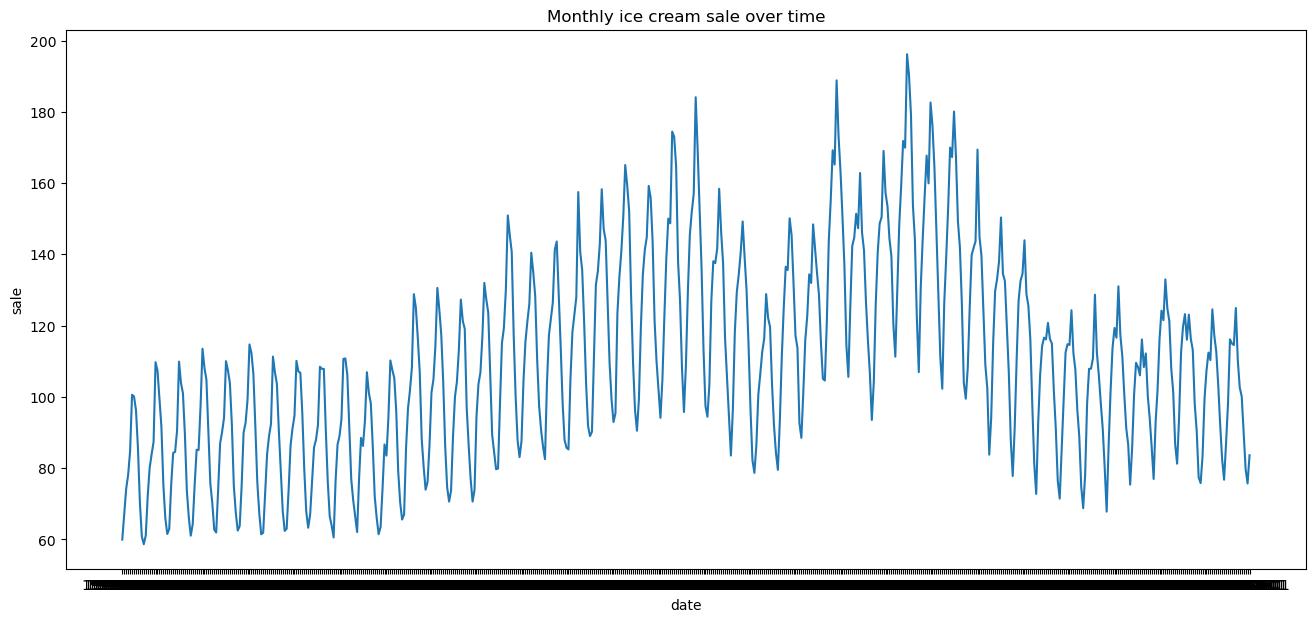

In [4]:
plt.figure(figsize=(16,7))
sns.lineplot(x=df['date'],y=df['sale'])
plt.title('Monthly ice cream sale over time')
plt.show()

#### Decompose to check trend and seasonality
- Observed (original data) - The actual data we started with
- Trend - Long term movement or direction in the data
- Seasonal - Repeating pattern that occours at regular intervals
- Residual - Noise or irregularities left removing trend and seasonality
- Note: To see cyclicality we need ADF (TBD)

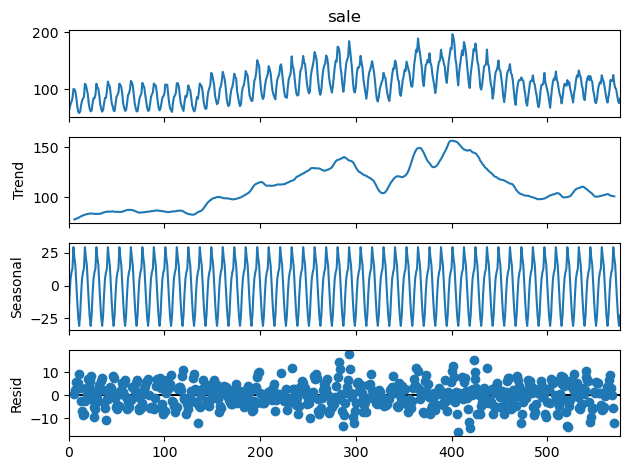

In [5]:
decomposition = seasonal_decompose(df.sale, period = 12)
decomposition.plot()
plt.show()

#### Stationary Check

In [6]:
def test_stationarity(dataFrame, var, window = 12):
    dataFrame['rollMean'] = dataFrame[var].rolling(window=window).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=window).std()
    adf_result = adfuller(dataFrame[var])
    p_value = adf_result[1]

    print(f'ADF p_value: {p_value:.4f}')
    if p_value < 0.05:
        print('The time series is stationary (reject H0)')
    else:
        print("The time series is not stationary (fail to reject H0)")

    plt.figure(figsize=(10,5))
    sns.lineplot(x=dataFrame.date,y=dataFrame[var],label='Original')
    sns.lineplot(x=dataFrame.date, y=dataFrame['rollMean'],label='Rolling Mean')
    sns.lineplot(x=dataFrame.date, y=dataFrame['rollStd'],label = 'Rolling Std')
    plt.title('Rolling Stastics')
    plt.legend()
    plt.show()


ADF p_value: 0.4015
The time series is not stationary (fail to reject H0)


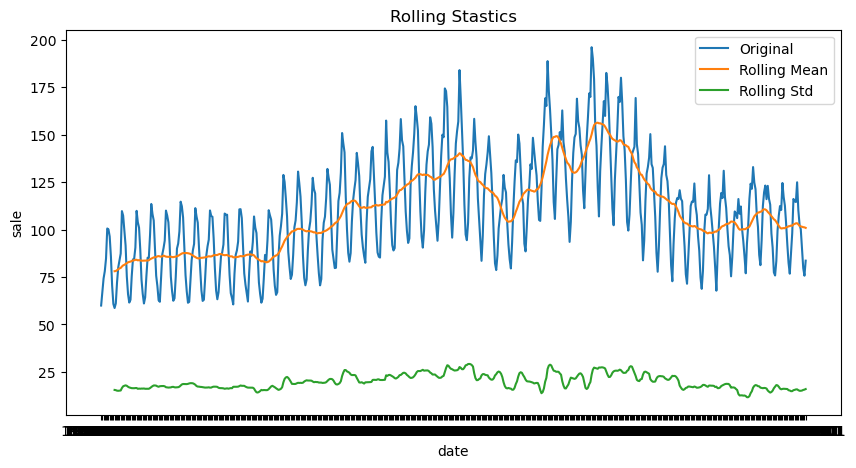

In [7]:
### Test Stationarity
test_stationarity(df,'sale')

### Not Stationary ... Try with diff of 1

          date      sale   rollMean    rollStd     shift  shiftDiff
0   1972-01-01   59.9622        NaN        NaN       NaN        NaN
1   1972-02-01   67.0605        NaN        NaN   59.9622     7.0983
2   1972-03-01   74.2350        NaN        NaN   67.0605     7.1745
3   1972-04-01   78.1120        NaN        NaN   74.2350     3.8770
4   1972-05-01   84.7636        NaN        NaN   78.1120     6.6516
5   1972-06-01  100.5960        NaN        NaN   84.7636    15.8324
6   1972-07-01  100.1263        NaN        NaN  100.5960    -0.4697
7   1972-08-01   96.3607        NaN        NaN  100.1263    -3.7656
8   1972-09-01   85.8007        NaN        NaN   96.3607   -10.5600
9   1972-10-01   70.3934        NaN        NaN   85.8007   -15.4073
10  1972-11-01   60.8072        NaN        NaN   70.3934    -9.5862
11  1972-12-01   58.6598  78.073117  15.464092   60.8072    -2.1474
12  1973-01-01   61.0996  78.167900  15.346029   58.6598     2.4398
13  1973-02-01   72.2062  78.596708  15.076977  

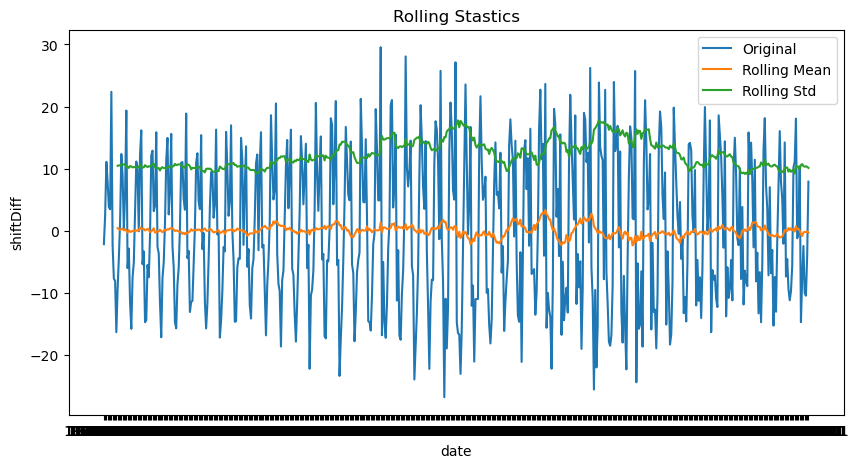

In [8]:
df['shift'] = df.sale.shift(1)
df['shiftDiff'] = df['sale'] - df['shift']
print(df.head(20))
test_stationarity(df.dropna(),'shiftDiff')


### Not Stationary ... Try with diff of 2

          date      sale   rollMean    rollStd     shift  shiftDiff
0   1972-01-01   59.9622        NaN        NaN       NaN        NaN
1   1972-02-01   67.0605        NaN        NaN       NaN        NaN
2   1972-03-01   74.2350        NaN        NaN   59.9622    14.2728
3   1972-04-01   78.1120        NaN        NaN   67.0605    11.0515
4   1972-05-01   84.7636        NaN        NaN   74.2350    10.5286
5   1972-06-01  100.5960        NaN        NaN   78.1120    22.4840
6   1972-07-01  100.1263        NaN        NaN   84.7636    15.3627
7   1972-08-01   96.3607        NaN        NaN  100.5960    -4.2353
8   1972-09-01   85.8007        NaN        NaN  100.1263   -14.3256
9   1972-10-01   70.3934        NaN        NaN   96.3607   -25.9673
10  1972-11-01   60.8072        NaN        NaN   85.8007   -24.9935
11  1972-12-01   58.6598  78.073117  15.464092   70.3934   -11.7336
12  1973-01-01   61.0996  78.167900  15.346029   60.8072     0.2924
13  1973-02-01   72.2062  78.596708  15.076977  

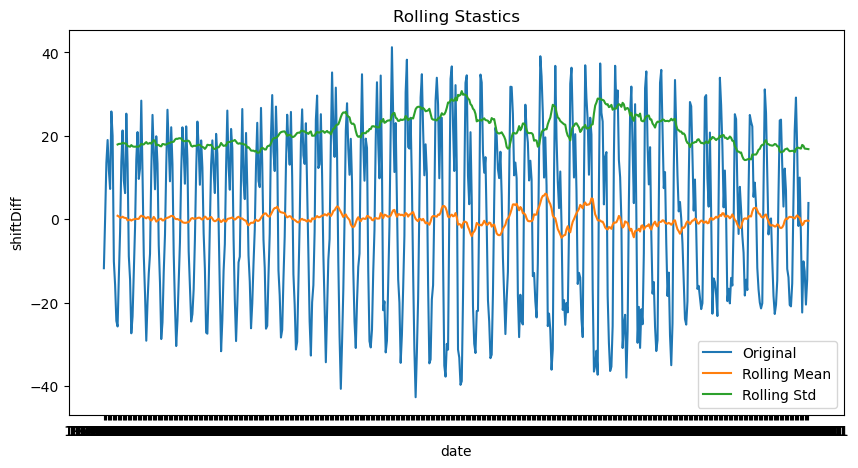

In [9]:
df['shift'] = df.sale.shift(2)
df['shiftDiff'] = df['sale'] - df['shift']
print(df.head(20))
test_stationarity(df.dropna(),'shiftDiff')

### Not Stationary ... Try with diff of 3

          date      sale   rollMean    rollStd     shift  shiftDiff
0   1972-01-01   59.9622        NaN        NaN       NaN        NaN
1   1972-02-01   67.0605        NaN        NaN       NaN        NaN
2   1972-03-01   74.2350        NaN        NaN       NaN        NaN
3   1972-04-01   78.1120        NaN        NaN   59.9622    18.1498
4   1972-05-01   84.7636        NaN        NaN   67.0605    17.7031
5   1972-06-01  100.5960        NaN        NaN   74.2350    26.3610
6   1972-07-01  100.1263        NaN        NaN   78.1120    22.0143
7   1972-08-01   96.3607        NaN        NaN   84.7636    11.5971
8   1972-09-01   85.8007        NaN        NaN  100.5960   -14.7953
9   1972-10-01   70.3934        NaN        NaN  100.1263   -29.7329
10  1972-11-01   60.8072        NaN        NaN   96.3607   -35.5535
11  1972-12-01   58.6598  78.073117  15.464092   85.8007   -27.1409
12  1973-01-01   61.0996  78.167900  15.346029   70.3934    -9.2938
13  1973-02-01   72.2062  78.596708  15.076977  

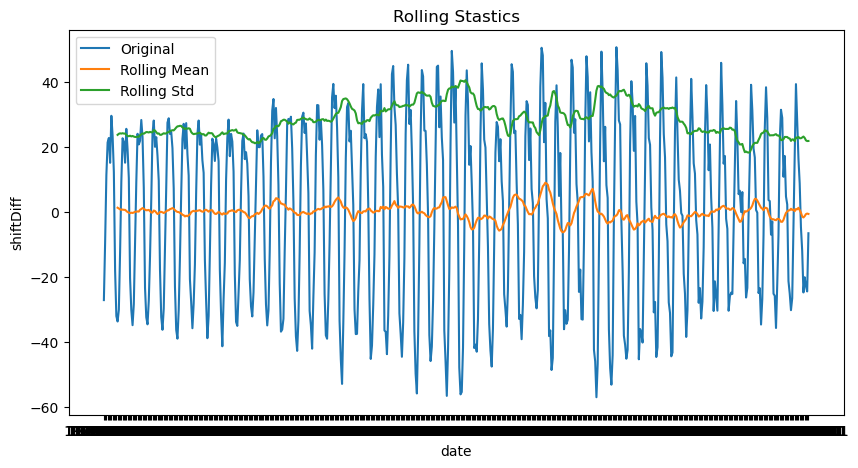

In [10]:
df['shift'] = df.sale.shift(3)
df['shiftDiff'] = df['sale'] - df['shift']
print(df.head(20))
test_stationarity(df.dropna(),'shiftDiff')

### For ACF - Differencing of 1 and 12

In [11]:
df['oneDiff'] = df['sale'].diff(1)
df['Diff12'] = df['sale'].diff(12)

In [12]:
df.head()

,date,sale,rollMean,rollStd,shift,shiftDiff,oneDiff,Diff12
0,1972-01-01,59.9622,NaN,NaN,NaN,NaN,NaN,NaN
1,1972-02-01,67.0605,NaN,NaN,NaN,NaN,7.0983,NaN
2,1972-03-01,74.2350,NaN,NaN,NaN,NaN,7.1745,NaN
3,1972-04-01,78.1120,NaN,NaN,59.9622,18.1498,3.8770,NaN
4,1972-05-01,84.7636,NaN,NaN,67.0605,17.7031,6.6516,NaN


### PACF and ACF Plots

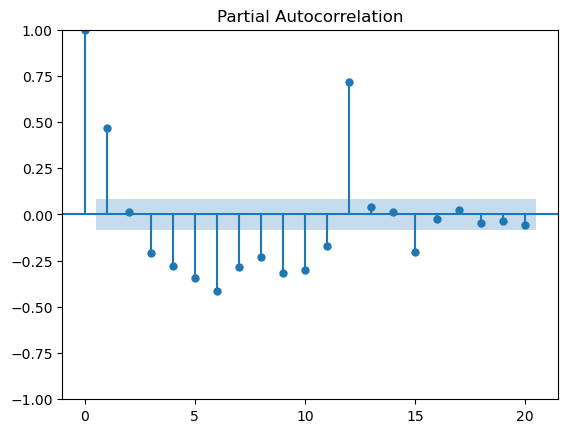

In [13]:
plot_pacf(df['oneDiff'].dropna(),lags=20)
plt.show()

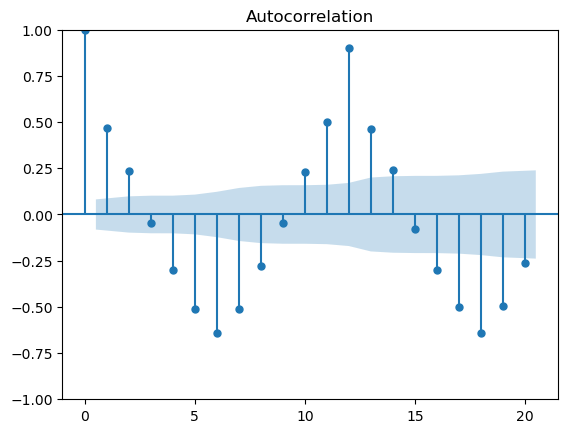

In [14]:
plot_acf(df['oneDiff'].dropna(),lags=20)
plt.show()

### Train-Test Split

In [15]:
train_size  = int(len(df) * 0.7)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

### ARIMA Model

In [16]:
model_arima = ARIMA(train['sale'], order=(12,0,0))
model_arima_fit = model_arima.fit()
arimaPred = model_arima_fit.predict(start=len(train), end=len(df)-1)

### Add ARIMA prediction to dataframe

In [17]:
df['arimaPred'] = np.nan
df.iloc[train_size:,df.columns.get_loc('arimaPred')] = arimaPred.values
print(df.tail())

           date      sale    rollMean    rollStd     shift  shiftDiff  \
572  2019-09-01  100.1741  101.678975  15.021611  124.9605   -24.7864   
573  2019-10-01   90.1684  101.515333  15.145254  110.2632   -20.0948   
574  2019-11-01   79.7223  101.289300  15.472611  102.6085   -22.8862   
575  2019-12-01   75.7094  101.201683  15.626348  100.1741   -24.4647   
576  2020-01-01   83.6290  100.920867  15.932076   90.1684    -6.5394   

     oneDiff  Diff12   arimaPred  
572  -2.4344 -3.1377  157.946558  
573 -10.0057 -1.9637  150.381943  
574 -10.4461 -2.7124  141.675827  
575  -4.0129 -1.0514  134.106787  
576   7.9196 -3.3698  129.636588  


### Plot

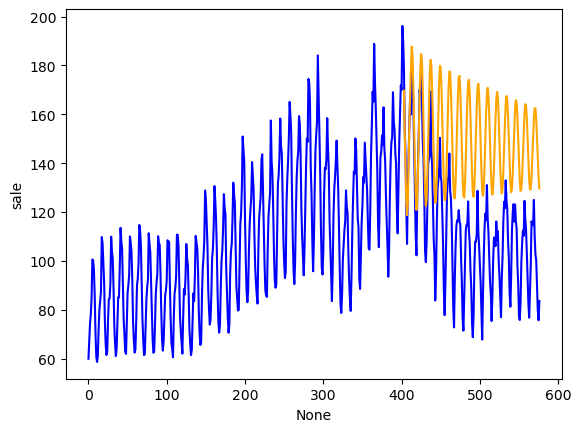

In [18]:
sns.lineplot(data=df, x=df.index, y='sale', color='blue')
sns.lineplot(data=df, x=df.index, y='arimaPred', color='orange')
plt.show()

### ARIMA predictions are poor, try SARIMAX

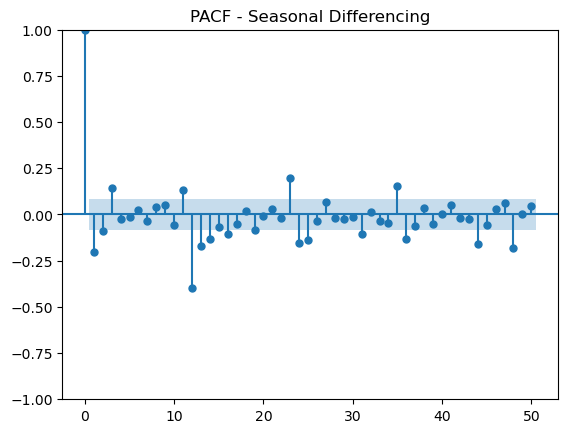

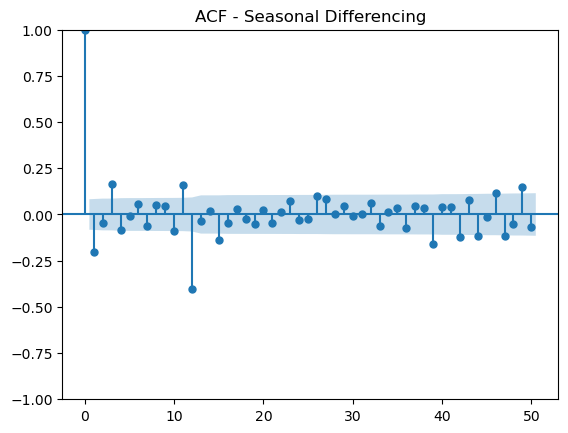

In [19]:
df['diff_combined'] = df['sale'].diff(1).diff(12)
plot_pacf(df['diff_combined'].dropna(),lags=50)
plt.title("PACF - Seasonal Differencing")
plt.show()

plot_acf(df['diff_combined'].dropna(),lags=50)
plt.title("ACF - Seasonal Differencing")
plt.show()

### SARIMAX

In [20]:
model_sarimax = SARIMAX(train['sale'], order=(11,0,0), seasonal_order=(1,0,0,12))
model_sarimax_fit = model_sarimax.fit()
sarimaxPred = model_sarimax_fit.predict(start=len(train),end=len(df)-1)

### Add SARIMAX predictions to dataframe

In [21]:
df['sarimaxPred'] = np.nan
df.iloc[train_size:,df.columns.get_loc('sarimaxPred')] = sarimaxPred.values
print(df.tail(20))

           date      sale    rollMean    rollStd     shift  shiftDiff  \
557  2018-06-01  124.5841  100.723308  15.997963  107.3152    17.2689   
558  2018-07-01  117.2215  100.803108  16.084682  112.4309     4.7906   
559  2018-08-01  112.6779  100.761958  16.050758  110.3544     2.3235   
560  2018-09-01  103.3118  101.211900  16.039293  124.5841   -21.2723   
561  2018-10-01   92.1321  101.350142  15.945196  117.2215   -25.0894   
562  2018-11-01   82.4347  101.766550  15.316821  112.6779   -30.2432   
563  2018-12-01   76.7608  101.845633  15.172399  103.3118   -26.5510   
564  2019-01-01   86.9988  102.142675  14.809736   92.1321    -5.1333   
565  2019-02-01   98.1116  102.027817  14.837499   82.4347    15.6769   
566  2019-03-01  116.1718  102.765867  15.336304   76.7608    39.4110   
567  2019-04-01  114.9703  102.977483  15.498452   86.9988    27.9715   
568  2019-05-01  114.5613  103.328058  15.726391   98.1116    16.4497   
569  2019-06-01  124.9605  103.359425  15.772948  1

### Plot

         date     sale  rollMean  rollStd    shift  shiftDiff  oneDiff  \
0  1972-01-01  59.9622       NaN      NaN      NaN        NaN      NaN   
1  1972-02-01  67.0605       NaN      NaN      NaN        NaN   7.0983   
2  1972-03-01  74.2350       NaN      NaN      NaN        NaN   7.1745   
3  1972-04-01  78.1120       NaN      NaN  59.9622    18.1498   3.8770   
4  1972-05-01  84.7636       NaN      NaN  67.0605    17.7031   6.6516   

   Diff12  arimaPred  diff_combined  sarimaxPred  
0     NaN        NaN            NaN          NaN  
1     NaN        NaN            NaN          NaN  
2     NaN        NaN            NaN          NaN  
3     NaN        NaN            NaN          NaN  
4     NaN        NaN            NaN          NaN  


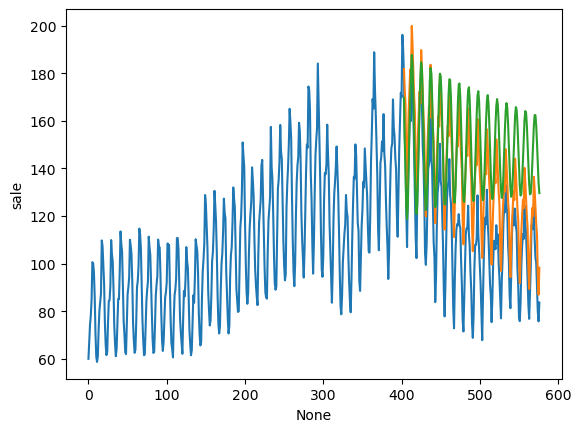

In [22]:

df.dropna()
print(df.head())
sns.lineplot(data=df,x=df.index,y='sale')
sns.lineplot(data=df,x=df.index,y='sarimaxPred')
sns.lineplot(data=df,x=df.index,y='arimaPred')
plt.show()

### Future Forecast using SARIMAX

In [23]:
future_dates = pd.DataFrame(pd.date_range(start='2021-01-01',end='2022-12-01',freq='MS'), columns=['Dates'])
#future_dates.set_index('Dates',inplace=True)

In [24]:
future_dates.tail()

,Dates
19,2022-08-01
20,2022-09-01
21,2022-10-01
22,2022-11-01
23,2022-12-01


In [25]:
future_forecast = model_sarimax_fit.predict(start=future_dates.index[0],end = future_dates.index[-1])

In [26]:
future_forecast

0       0.000000
1      55.930122
2      61.863434
3      67.083824
4      72.695168
5      78.553131
6      88.627016
7      90.545134
8      90.318011
9      79.996215
10     70.938677
11     62.690909
12     58.076593
13     67.392329
14     77.864291
15     82.874769
16     90.447948
17    103.168896
18    106.997787
19    102.645125
20     90.923512
21     75.908052
22     64.563739
23     63.053232
Name: predicted_mean, dtype: float64

In [27]:
df.head()

,date,sale,rollMean,rollStd,shift,shiftDiff,oneDiff,Diff12,arimaPred,diff_combined,sarimaxPred
0,1972-01-01,59.9622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1972-02-01,67.0605,NaN,NaN,NaN,NaN,7.0983,NaN,NaN,NaN,NaN
2,1972-03-01,74.2350,NaN,NaN,NaN,NaN,7.1745,NaN,NaN,NaN,NaN
3,1972-04-01,78.1120,NaN,NaN,59.9622,18.1498,3.8770,NaN,NaN,NaN,NaN
4,1972-05-01,84.7636,NaN,NaN,67.0605,17.7031,6.6516,NaN,NaN,NaN,NaN


### Plot the Future Forecast

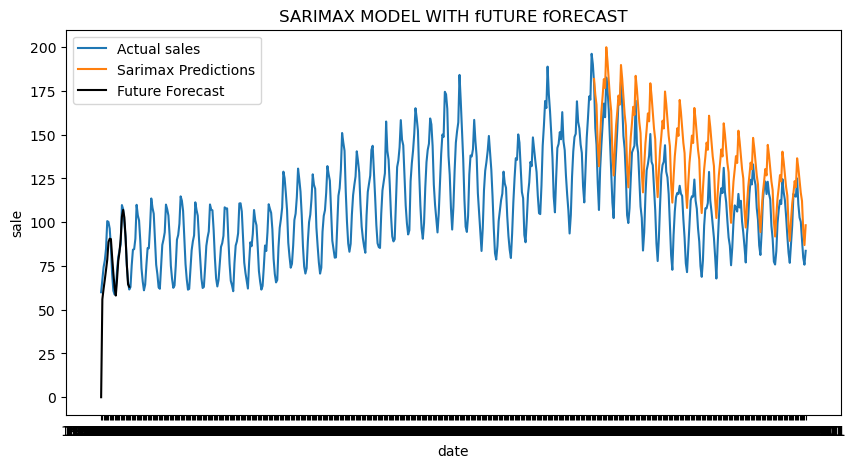

In [28]:
plt.figure(figsize=(10,5))
sns.lineplot(x=df.date,y=df['sale'],label='Actual sales')
sns.lineplot(x=df.date,y=df['sarimaxPred'],label='Sarimax Predictions')
future_forecast.plot(color='black',label='Future Forecast')
plt.title('SARIMAX MODEL WITH fUTURE fORECAST')
plt.legend()
plt.show()

### Model Evaluation

In [29]:
df = df.dropna()

### ARIMA

In [30]:
print(mean_absolute_error(df['sale'],df['arimaPred']))
print(mean_squared_error(df['sale'],df['arimaPred']))
print(r2_score(df['sale'],df['arimaPred']))

36.969707992308756
1684.2831965552405
-1.747497646432052


### SARIMAX

In [31]:
print(mean_absolute_error(df['sale'],df['sarimaxPred']))
print(mean_squared_error(df['sale'],df['sarimaxPred']))
print(r2_score(df['sale'],df['sarimaxPred']))

25.148974245266878
752.7519014002562
-0.22793131325799854


#### 2. Apply PCA on bank customer churn prediction dataset and show explained variance - then predict using the components instead of the original columns


In [32]:
df = pd.read_csv('Bank Customer Churn Prediction.csv',index_col=0)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
customer_id,,,,,,,,,,,
15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 15634602 to 15628319
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   products_number   10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 937.5+ KB


In [34]:
df['country'].value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [35]:
df['gender'].value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

In [36]:
df = pd.get_dummies(df, drop_first=True,dtype=int)
df.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
customer_id,,,,,,,,,,,,
15634602,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
15647311,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
15619304,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
15701354,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [37]:
X,y = df.drop('churn',axis=1),df['churn']


In [38]:
numerical_cols = ['credit_score','age','balance','products_number','credit_card','active_member','estimated_salary','country_Germany','country_Spain','gender_Male']

### Scaling

In [39]:
from sklearn.preprocessing import MinMaxScaler
numerical_data = df[numerical_cols]
scaler = MinMaxScaler().set_output(transform='pandas')
X_scaled = scaler.fit_transform(numerical_data)


In [40]:
X_scaled.head()

,credit_score,age,balance,products_number,credit_card,active_member,estimated_salary,country_Germany,country_Spain,gender_Male
customer_id,,,,,,,,,,
15634602,0.538,0.324324,0.000000,0.000000,1.0,1.0,0.506735,0.0,0.0,0.0
15647311,0.516,0.310811,0.334031,0.000000,0.0,1.0,0.562709,0.0,1.0,0.0
15619304,0.304,0.324324,0.636357,0.666667,1.0,0.0,0.569654,0.0,0.0,0.0
15701354,0.698,0.283784,0.000000,0.333333,0.0,0.0,0.469120,0.0,0.0,0.0
15737888,1.000,0.337838,0.500246,0.000000,1.0,1.0,0.395400,0.0,1.0,0.0


### Apply PCA

In [41]:
from sklearn.decomposition import PCA
pca = PCA(10)              ## keep all component
X_pca = pca.fit_transform(X_scaled)


### Variance Captured by each component

In [42]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

### Plot Cumulative Variance

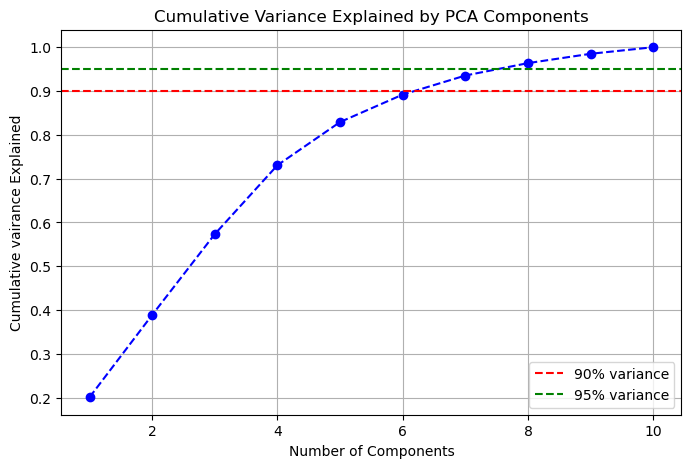

In [43]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--',color='b')
plt.title('Cumulative Variance Explained by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative vairance Explained')
plt.axhline(y=0.9, color='r',linestyle='--',label='90% variance')
plt.axhline(y=0.95, color='g',linestyle='--',label='95% variance')
plt.legend()
plt.grid()
plt.show()

### Display PCA results

In [44]:
print('\nExplained Variance Ratio(For each PC)')
print(explained_variance)
print('\nCumulative variance')
print(cumulative_variance)


Explained Variance Ratio(For each PC)
[0.20083592 0.18797843 0.18457457 0.15723535 0.09858112 0.06265229
 0.04352984 0.0283121  0.02129988 0.01500051]

Cumulative variance
[0.20083592 0.38881435 0.57338892 0.73062426 0.82920538 0.89185767
 0.93538751 0.9636996  0.98499949 1.        ]


### Show composition (loadings) of each Principal Component

In [45]:
loadings = pd.DataFrame(
    pca.components_,
    columns=numerical_cols,
    index=[f'PC{i+1}' for i in range(len(numerical_cols))]
)
print('\nComposition of each Principal Component: ', loadings)


Composition of each Principal Component:        credit_score       age   balance  products_number  credit_card  \
PC1      -0.004259 -0.000881  0.156334        -0.011869     0.051879   
PC2       0.007494  0.020242  0.135295        -0.014164     0.013883   
PC3      -0.008283 -0.022334  0.026536        -0.012968     0.079600   
PC4      -0.001919 -0.002362 -0.028779         0.005365     0.995103   
PC5       0.006867  0.017984  0.241897        -0.038140     0.014627   
PC6      -0.001253 -0.004843  0.004009         0.016561     0.010746   
PC7      -0.008448  0.012788  0.775878        -0.560943     0.013157   
PC8       0.998516 -0.012910  0.032296         0.037077     0.002921   
PC9      -0.051179 -0.070683  0.541902         0.822945     0.004735   
PC10      0.008936  0.996701  0.022465         0.066806     0.003898   

      active_member  estimated_salary  country_Germany  country_Spain  \
PC1       -0.466219          0.013458         0.560694      -0.514787   
PC2        0.65761

### Select First three Principal components

In [46]:
X_selected = X_pca[:,:3]

### Prepare the target variable

In [47]:
y=df['churn']

### Split data into training and testing sets

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2,stratify=y,random_state=42)

In [49]:
pip install -U scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [50]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)




### Train a Logistic Regression Model on Components

In [51]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_balanced,y_train_balanced)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Make Prediction

In [52]:
ypred = log_reg.predict(X_test)

### Evaluate Model

In [53]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
accuracy = accuracy_score(y_test,ypred)
cm = confusion_matrix(y_test,ypred)
report = classification_report(y_test,ypred)

print('\n Model Accuracy using first 3 Principal components:')
print("Accuracy : ",accuracy)
print("confusion Matrix : \n ",cm)
print("Classification Report: \n",report)


 Model Accuracy using first 3 Principal components:
Accuracy :  0.6105
confusion Matrix : 
  [[953 640]
 [139 268]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.87      0.60      0.71      1593
           1       0.30      0.66      0.41       407

    accuracy                           0.61      2000
   macro avg       0.58      0.63      0.56      2000
weighted avg       0.76      0.61      0.65      2000



### Display actual vs predicted values

In [54]:
comparison = pd.DataFrame({'Actual':y_test, 'Predicted': ypred})
print('\nActual vs Predicted values: ')
print(comparison.head())


Actual vs Predicted values: 
             Actual  Predicted
customer_id                   
15749540          0          1
15807340          0          1
15801062          0          0
15572801          0          0
15600708          0          0


## 3. Create a decision tree on same dataset

In [55]:
from sklearn.tree import DecisionTreeClassifier
dtClassifier = DecisionTreeClassifier(criterion='entropy',max_depth=200)
dtClassifier.fit(X_train_balanced,y_train_balanced)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",200
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamp

In [56]:
ypred = dtClassifier.predict(X_test)

In [57]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
accuracy = accuracy_score(y_test,ypred)
cm = confusion_matrix(y_test,ypred)
report = classification_report(y_test,ypred)

print('\n Model Accuracy using first 3 Principal components:')
print("Accuracy : ",accuracy)
print("confusion Matrix : \n ",cm)
print("Classification Report: \n",report)


 Model Accuracy using first 3 Principal components:
Accuracy :  0.7165
confusion Matrix : 
  [[1224  369]
 [ 198  209]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.77      0.81      1593
           1       0.36      0.51      0.42       407

    accuracy                           0.72      2000
   macro avg       0.61      0.64      0.62      2000
weighted avg       0.76      0.72      0.73      2000



## 4. Solve the following LPP using PuLP:
You are the captain of a cricket team and need to allocate overs to two bowlers, 
Bowler A and Bowler B, to maximize the number of wickets they can take.

Constraints:
Bowler A can bowl a maximum of 6 overs.
Bowler B can bowl a maximum of 8 overs.
Together, they can bowl a total of 10 overs.

Bowler A takes an average of 0.5 wickets per over.
Bowler B takes an average of 0.3 wickets per over.

In [59]:
from pulp import *

In [ ]:
import pulp
from pulp import LpProblem, LpMaximize, LpVariable, value, LpStatus

# 1. Initialize the optimization problem (Maximize)
prob = LpProblem("CricketProblem", LpMaximize)

# 2. Define the decision variables
xA = LpVariable('Overs_Bowler_A', lowBound=0, upBound=6, cat='Continuous')
xB = LpVariable('Overs_Bowler_B', lowBound=0, upBound=8, cat='Continuous')

# 3. Define the Objective Function
prob += 0.5 * xA + 0.3 * xB, "Total_Wickets"

# 4. Define the Constraints
prob += xA + xB <= 10, "Total_Overs_Constraint"

# 5. Solve the problem
status = prob.solve()



Status: Optimal
Overs allocated to Bowler A: 6.0 overs
Overs allocated to Bowler B: 4.0 overs
Maximum Expected Wickets: 4.2
Status: Optimal
Overs allocated to Bowler A: 6.0 overs
Overs allocated to Bowler B: 4.0 overs
Maximum Expected Wickets: 4.2
Status: Optimal
Overs allocated to Bowler A: 6.0 overs
Overs allocated to Bowler B: 4.0 overs
Maximum Expected Wickets: 4.2
Status: Optimal
Overs allocated to Bowler A: 6.0 overs
Overs allocated to Bowler B: 4.0 overs
Maximum Expected Wickets: 4.2
Status: Optimal
Overs allocated to Bowler A: 6.0 overs
Overs allocated to Bowler B: 4.0 overs
Maximum Expected Wickets: 4.2


In [63]:
# 6. Print the results
# Fix: Using the directly imported LpStatus dictionary

print(f"Status: {LpStatus[status]}")
print(f"Overs allocated to Bowler A: {value(xA)} overs")
print(f"Overs allocated to Bowler B: {value(xB)} overs")
print(f"Maximum Expected Wickets: {value(prob.objective)}")

Status: Optimal
Overs allocated to Bowler A: 6.0 overs
Overs allocated to Bowler B: 4.0 overs
Maximum Expected Wickets: 4.2
